# Assignment 7
### Do any five.

In [79]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import norm, poisson, gaussian_kde
from statsmodels.distributions.empirical_distribution import ECDF

## 1. 

- What is the expected value of a single die roll? 
- What is the expected value of rolling two dice and adding the results together?
- What is the expected winnings of any gamble in European roulette?

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?
- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

-  What is the expected value of a single die roll? 

The expected value of a single die roll is the sum of the expected values times each of their probabilities. In this case the probability of one side of the die to land is 1/6 and there are 6 different values: 1, 2, 3, 4, 5, 6. The answer would be 1/6(1) + 1/6(2) + 1/6(3) + 1/6(4) + 1/6(5) + 1/6(6) = so the expected value is 21/6 = 3.5.

- What is the expected value of rolling two dice and adding the results together?

This is very similar to the last problem. You take the sum of the expected values multiplied by each of their probabilities. So in this case 2(1/36) + 3(2/36) + 4(3/36) + 5(4/36) + 6(5/36) + 7(6/36) + 8(5/36) + 9(4/36) + 10(3/36) + 11(2/36) + 12(1/36) = 252/36 = 7 

- What is the expected winnings of any gamble in European roulette?

In the game of European Roulette there are 37 outcomes 1 through 36 and then 0. so the probability of you winning is 1/37 based on how many spots you bet on. So say you bet on 1, 2, 3 then the probability would be 3/37. Now lets talk about the payoff. If the number of slots you bet on is represented by X then the expected winnings would be 36/X but then there is a chance that you do not make any money and that chance would be (37-X/37) so if we combine all of this together we get X/37 * 36/X + 37-X/37 * 0 - 1 = if we simplify this would be 36/37 - 1 = - 1/37 which is the expected winnings.

- Imagine you roll a die, and you record the value you get. But, if you roll a six, you roll again, and add that value. What is the expected value?

The expected value of this would be very similar to the first one you take the probability of the roll being a side of the die and multiply it by the number however, if it lands on 6 then you roll again and add the value. Which means that instead of multiplying by just 6 we would multiply by the expected value of rolling another dice. So the expected value would be 1/6(1) + 1/6(2) + 1/6(3) + 1/6(4) + 1/6(5) + 1/6(6 + 3.5) We add the extra 3.5 because that is the expected value of rolling another die. which we derived in question 1. So the expected value would be 21/6 + 3.5 = 27/6 = 4.5

- Imagine that the process described in the last question continues until you fail to roll a six. What is the expected value of the process? (This can be tricky, you can simulate it to get an answer if you prefer. Hint: The answer is 4.2.)

For this problem it is very similar to the last problem where we had the final equation as 1/6(1) + 1/6(2) + 1/6(3) + 1/6(4) + 1/6(5) + 1/6(6 + 3.5) but instead of 3.5 we replace it with X iterations so its X = 1/6(1) + 1/6(2) + 1/6(3) + 1/6(4) + 1/6(5) + 1/6(6 + X) = 21/6 + X/6 so X = 21/5 = 4.2

## 2. 
- Compute the expected value for a uniform random variable.
- Show that $\mathbb{E}[a+bX] = a + b\mathbb{E}[X]$
- Show, by example, that $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$, if $v(x) \neq a+bx$. For example, try $v(y) = y^2$ or $v(y)=\sqrt{y}$ with a Bernoulli or uniform or normally distributed random variable. This can be an important thing to remember: The expectation of a transformed random variable is not the transformation of the expected value.

- Compute the expected value for a uniform random variable.


for a uniform random variable between 0 and 1 the expected value is 0.5. The expected value of a uniform random variable is that because each variable between 0 and 1 has a equally likely chance of being selected so the expected value would be the midpoint of the range. which is 0.5.

- Show that $\mathbb{E}[a+bX] = a + b\mathbb{E}[X]$
This is basically a property of the integral:
$$
\mathbb{E}[a+bX] = \int_{-\infty}^{+\infty} (a + bx)f(x)dx = \int_{-\infty}^{+\infty} af(x) + bxf(x)dx = a \int_{-\infty}^{+\infty} f(x)dx + b \int_{-\infty}^{+\infty} xf(x)dx =a + b \mathbb{E}[X]
$$
since $ \int_a^b f(x) dx = F(b) - F(a)$, and $F(-\infty)=0$ and $F(+\infty)=1$.

- Show, by example, that $v(\mathbb{E}[X]) \neq \mathbb{E}[v(X)]$, if $v(x) \neq a+bx$. For example, try $v(y) = y^2$ or $v(y)=\sqrt{y}$ with a Bernoulli or uniform or normally distributed random variable. This can be an important thing to remember: The expectation of a transformed random variable is not the transformation of the expected value.

Expected Value: 0.6655770418938949
Value of Expectation: 0.7062793725043546


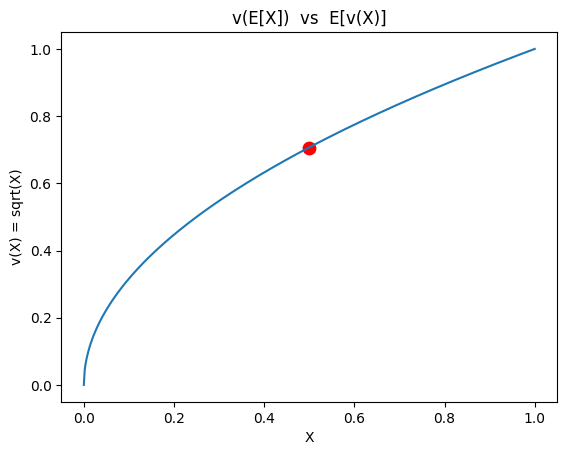

In [61]:
X = np.random.uniform(0, 1, size=100000)
v = np.sqrt

E_vX = np.mean(v(X))
v_E_X = v(np.mean(X))      

print("Expected Value:", E_vX)
print("Value of Expectation:", v_E_X)

x_vals = np.linspace(0, 1, 500)
y_vals = v(x_vals)
plt.plot(x_vals, y_vals)
plt.scatter(np.mean(X), v_E_X, color='red', s=80)
plt.xlabel("X")
plt.ylabel("v(X) = sqrt(X)")
plt.title("v(E[X])  vs  E[v(X)]")
plt.show()

## 3. 
- Compute the variance for a uniform random variable.
- Show that 
$$
\mathbb{V}[X] = \mathbb{E}[X^2] - \mathbb{E}[X]^2
$$
$$
\mathbb{V}[a+bX] = b^2 \mathbb{V}[X]
$$
- Show that if $X$ is a normally distributed random variable, then $a + bX$ is distributed normally with mean $a+ b \mathbb{E}[X]$ and variance $b^2 \sigma_X^2$ 

These properties get used all the time!


## 4.

- The **covariance** of $X$ and $Y$ is
$$
\text{cov}(X,Y) = \int_{y} \int_{x} (x-\mathbb{E}[X])(y-\mathbb{E}[Y])f_{XY}(x,y) dxdy = \mathbb{E}_{XY}[ (x-\mu_X)(y-\mu_Y)]
$$
- Show that if $f_{XY}(x,y)=f_X(x)f_Y(y)$, then $\text{cov}(X,Y)=0$
- Provide an example (computation/simulation is fine) where $\text{cov}(X,Y)\approx 0$ but $f_{XY}(x,y)\neq 0$
- The covariance doesn't characterize joint random variables except in a few special cases: The covariance only captures the **linear** association between the two variables, not nonlinear associations.

## 5. 

Suppose $X$ has an expectation $\mathbb{E}[X]<\infty$ and variance $\mathbb{V}[X]<\infty$; this isn't always true, but is *usually* true
- Consider making a new variable, $\varepsilon = X - \mathbb{E}[X]$
- What's the expectation of $\varepsilon$?
- What's the variance of $\varepsilon$?
- So we can write any random variable in the form $X = \mathbb{E}[X] + \varepsilon, $ where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon] = \sigma_X^2$
- If that's true, show that we can also write any random variable in the form $X = \mathbb{E}[X] + \sigma_X \varepsilon$, where $\mathbb{E}[\varepsilon]=0$ and $\mathbb{V}[\varepsilon]=1$
- Now replace $\mathbb{E}[X]$ with $x\beta$, and the stage is set for regression models

## 6.
- Use the Taylor series expansions 
$$
F(x+h) = F(x) + hf(x) + \frac{h^2}{2}f'(x) + O(h^3)
$$ 
and 
$$
F(x-h) = F(x) - h f(x) + \frac{h^2}{2} f'(x)+ O(h^3)
$$
to show that
$$
\mathbb{E}[\hat{f}_{X,h}(x)] = \frac{F(x+h)-F(x-h)}{2h} = f(x) + O(h^2),
$$
so the **bias** of the KDE is $O(h^2)$, unlike the ECDF, for which $\mathbb{E}[\hat{F}(x)] = F(x)$.

## 7.
- Suppose $X$ and $Y$ are distributed bivariate normal. Show that if $\rho=0$, then $X$ and $Y$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix, then $X_1, X_2, ..., X_n$ are independent.
- For the multivariate normal, show that if $\Sigma$ is a diagonal matrix and all the $\sigma_i^2$ and all the $\mu_i$ are equal, then $X_1, X_2, ..., X_n$ are independently distributed random variables with distribution $N(\mu, \sigma^2)$

## 8.
- Open the METABRIC data. Make a histogram of 'Ratio Therapy'.
- Let treatment, $T$ be distributed binomial with parameter $p$. Then the contribution to the likelihood for each patient $i$, with $y_i = 0$ for no radiation therapy and $y_i=1$ for radiation therapy, is 
$$
p^{y_i}(1-p)^{1-y_i}
$$
- Write out the likelihood.
- Maximize the likelihood with respect to $p$. What is the MLE, $\hat{p}$?
- Bootstrap the sampling density/distribution of $\hat{p}$.

<Axes: xlabel='Radio Therapy', ylabel='Count'>

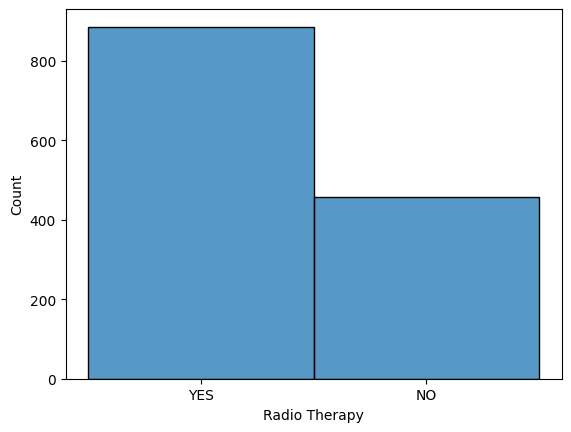

In [87]:
meta = pd.read_csv('/Users/jackjoy/Desktop/Jack Joy/UVA/Classes/Understanding_Uncertainty/UUAssignments/data/metabric.csv')

y = meta['Radio Therapy']
sns.histplot(y)

- Write out the likelihood.

$$
L(p) = \prod_{i=1}^n p^{y_i}(1-p)^{1-y_i}

- Maximize the likelihood with respect to $p$. What is the MLE, $\hat{p}$?

After maximizing the likelihood, we get that MLE is:

$$
\hat{p} = \dfrac{1}{n} \sum_{i=1}^n y_i.

- Bootstrap the sampling density/distribution of $\hat{p}$.

In [88]:
y = pd.to_numeric( y.replace({'NO':'0','YES':'1'}) , errors='coerce' )
print(f'MLE: ', y.mean())

MLE:  0.659717051377513


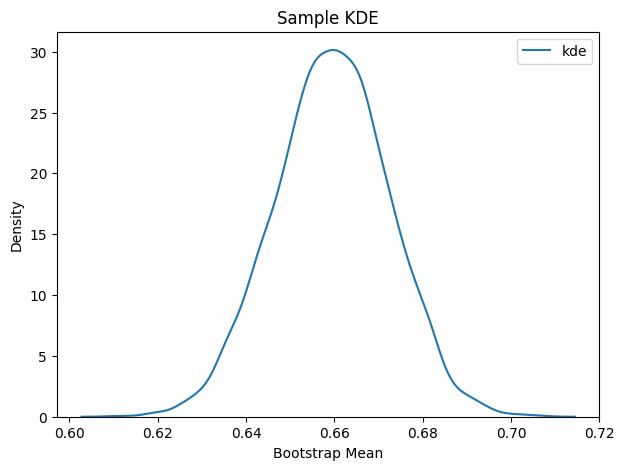

In [89]:
S = 5000
sample = [np.mean(y.sample(frac=1, replace=True)) for _ in range(S)]

# KDE plot
plt.figure(figsize=(7,5))
sns.kdeplot(x=sample, label='kde')
plt.title('Sample KDE')
plt.xlabel('Bootstrap Mean')
plt.ylabel('Density')
plt.legend()
plt.show()

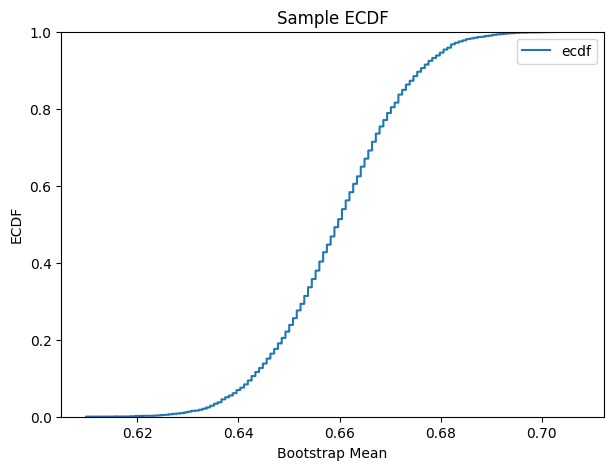

In [90]:
plt.figure(figsize=(7,5))
sns.ecdfplot(x=sample, label='ecdf')
plt.title('Sample ECDF')
plt.xlabel('Bootstrap Mean')
plt.ylabel('ECDF')
plt.legend()
plt.show()

## 9.
- Open the Ames house price data. Make a KDE of 'price'. Select an appropriate distribution for modeling it, and explain why you selected it. (Hint: You might want to take a common transformation of price.)
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood. What is the MLE?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameters.

In [91]:
ames = pd.read_csv('/Users/jackjoy/Desktop/Jack Joy/UVA/Classes/Understanding_Uncertainty/UUAssignments/data/ames_prices.csv')

In [92]:
ames.head()

,Order,PID,area,price,MS.SubClass,MS.Zoning,Lot.Frontage,Lot.Area,Street,Alley,...,Screen.Porch,Pool.Area,Pool.QC,Fence,Misc.Feature,Misc.Val,Mo.Sold,Yr.Sold,Sale.Type,Sale.Condition
0,1,526301100,1656,215000,20,RL,141.0,31770,Pave,NaN,...,0,0,NaN,NaN,NaN,0,5,2010,WD,Normal
1,2,526350040,896,105000,20,RH,80.0,11622,Pave,NaN,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
2,3,526351010,1329,172000,20,RL,81.0,14267,Pave,NaN,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
3,4,526353030,2110,244000,20,RL,93.0,11160,Pave,NaN,...,0,0,NaN,NaN,NaN,0,4,2010,WD,Normal
4,5,527105010,1629,189900,60,RL,74.0,13830,Pave,NaN,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal


I have had a lot of experience working with house pricing data and in the past I have used the log of the price as a transformation. That usually makes it more normally distributed. 

<Axes: xlabel='price', ylabel='Count'>

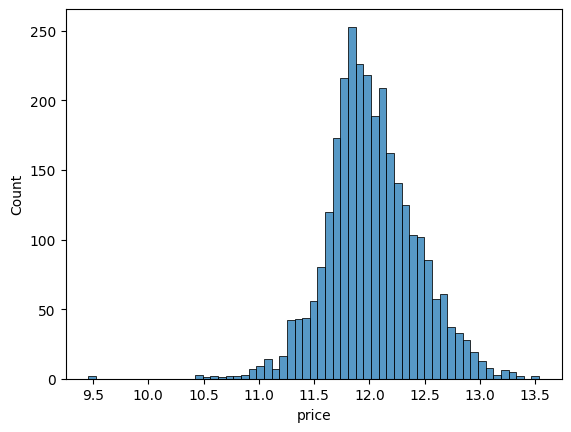

In [93]:
y = np.log(ames['price'])
sns.histplot(y)

The density function for our distribution is:

$$
f(y, \mu, \sigma) = \dfrac{1}{\sqrt{2\pi} \sigma}e^{-\frac{1}{2}\left( \frac{y-\mu}{\sigma} \right)^2}

The likelihood function is:

$$
L(\mu, \sigma) = \prod_{i=1}^n \dfrac{1}{\sqrt{2\pi} \sigma}e^{-\frac{1}{2}\left( \frac{y_i-\mu}{\sigma} \right)^2}.


In [94]:
mu = np.log(ames['price']).mean()
sigma = np.log(ames['price']).std(ddof=0)

x_vals = np.linspace(np.log(ames['price']).min(), np.log(ames['price']).max(), 500)
normal_pdf = norm.pdf(x_vals, mu, sigma)

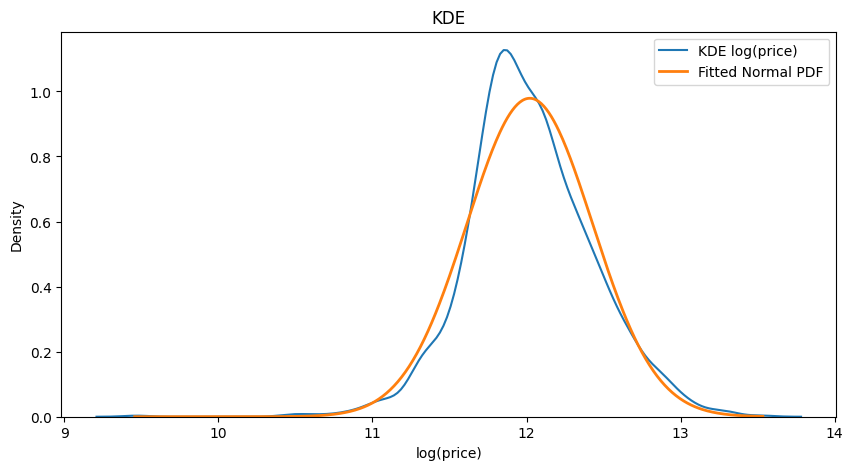

In [95]:
plt.figure(figsize=(10,5))
sns.kdeplot(np.log(ames['price']), label="KDE log(price)")
plt.plot(x_vals, normal_pdf, label="Fitted Normal PDF", linewidth=2)
plt.title("KDE")
plt.xlabel("log(price)")
plt.ylabel("Density")
plt.legend()
plt.show()

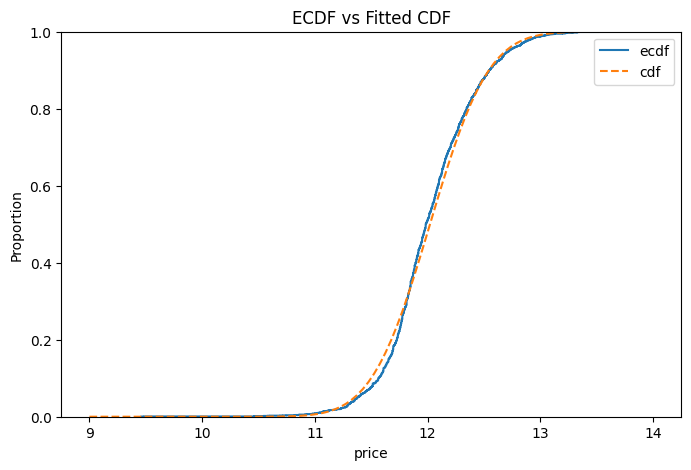

In [96]:
grid = np.linspace(9, 14, 100)
cdf = norm.cdf(grid, loc=mu, scale=sigma)

plt.figure(figsize=(8,5))

sns.ecdfplot(x=y, label='ecdf')
plt.plot(grid, cdf, '--', label='cdf')

plt.title("ECDF vs Fitted CDF")
plt.xlabel("price")
plt.ylabel("Proportion")
plt.legend()

plt.show()

When comparing the two models the ECDF definitely looks like a better fit for the data. YOu can very clearly see the lines are overlapping in the ECDF plot. When looking at the KDE plot you can see that the two lines are pretty similar. The KDE has a higher peak and is a bit more spread out but thats about it.

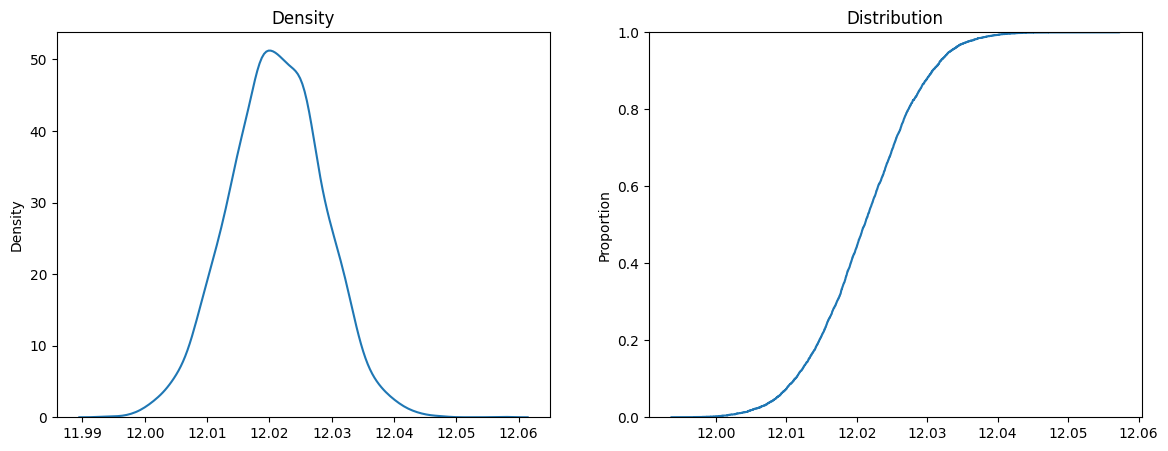

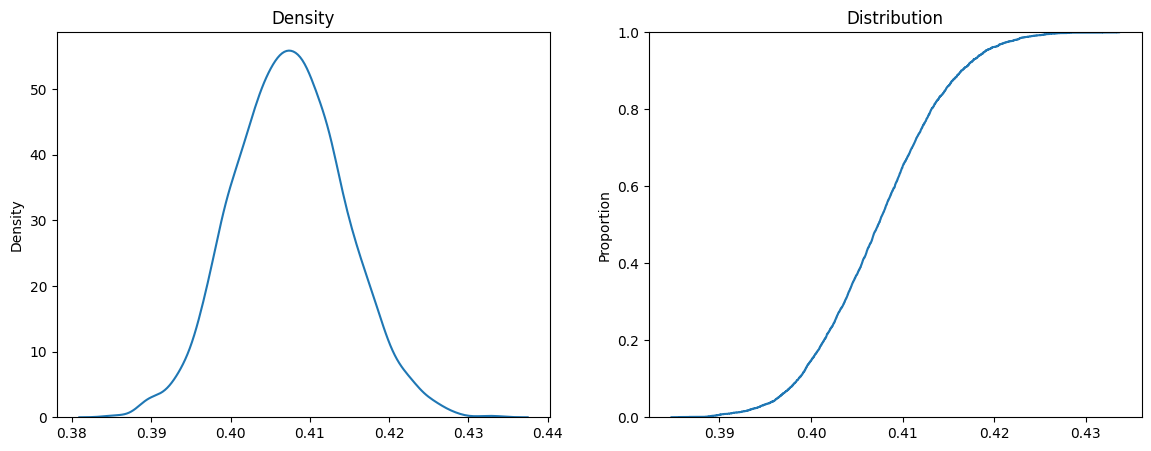

In [97]:
# Bootstrapping:
def mle(y):
    mu = np.mean(y)
    sigma = np.sqrt( np.mean( (y-mu)**2 ) )
    return mu, sigma

S = 5000
sample = [ mle(y.sample(frac=1.0,replace=True)) for s in range(S)]

mu_sample = [ row[0] for row in sample]
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=mu_sample,ax=axes[0],label='kde')
axes[0].set_title('Density')
sns.ecdfplot(x=mu_sample,ax=axes[1],label='ecdf')
axes[1].set_title('Distribution')
plt.show()

sigma_samples = [ row[1] for row in sample]
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.kdeplot(x=sigma_samples,ax=axes[0],label='kde')
axes[0].set_title('Density')
sns.ecdfplot(x=sigma_samples,ax=axes[1],label='ecdf')
axes[1].set_title('Distribution')
plt.show()

## 10.
- Open the METABRIC data. Make a KDE of 'Overall Survival (Months)'.
- Let survival time, $T$ be distributed exponentially with parameter $\lambda$. Then its distribution is
$$
F(t) = 1 - e^{-\lambda t} = p[T\le t].
$$
- Derive the density for this distribution.
- Write out the likelihood.
- Maximize the likelihood with respect to $\lambda$. What is the MLE, $\hat{\lambda}$?
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of $\hat{\lambda}$.

## 11.
- Open the Ames house price data. Make a histogram of 'TotRms.AbvGrd', or total rooms above ground.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

## 12.
- Open the METABRIC data. Make a histogram of 'Mutation Count' with around 50 bins. Let $Y$ be the mutation count the random variable, and $y_i$ the mutation count for patient $i$.
- We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}
$$
- Write out the likelihood.
- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)
- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.
- Bootstrap the sampling density/distribution of your parameter.

- Open the METABRIC data. Make a histogram of 'Mutation Count' with around 50 bins. Let $Y$ be the mutation count the random variable, and $y_i$ the mutation count for patient $i$.

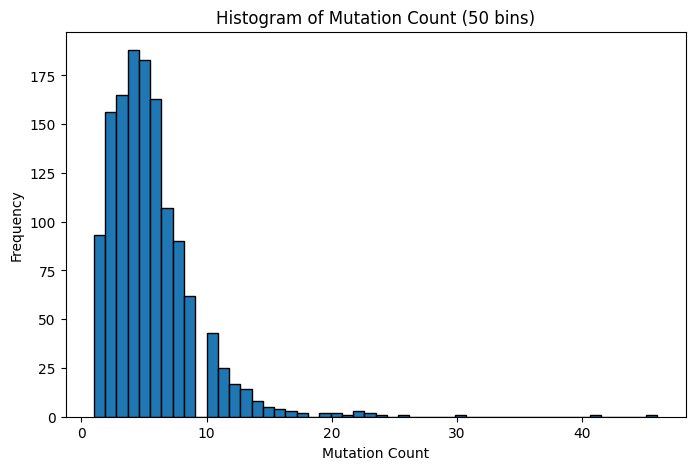

In [98]:
plt.figure(figsize=(8,5))
plt.hist(meta['Mutation Count'].dropna(), bins=50, edgecolor='black')
plt.xlabel('Mutation Count')
plt.ylabel('Frequency')
plt.title('Histogram of Mutation Count (50 bins)')
plt.show()

We're going to model this using the Poisson Distribution. The probability that $y_i = k$ is given by
$$
pr[y_i = k ] = \frac{ \lambda^k e^{-\lambda} }{k!}


- Write out the likelihood.


$$
L(\lambda)
= \lambda^{\sum_{i=1}^n y_i} \, e^{-n\lambda} \,
\prod_{i=1}^n \frac{1}{y_i!}.


- Maximize the likelihood. What is the MLE? (Hint: The sample mean. As usual.)


Take the log-likelihood:

$$
\ell(\lambda)
= \left( \sum_{i=1}^n y_i \right)\log(\lambda)
- n\lambda
- \sum_{i=1}^n \log(y_i!).
$$

Differentiate with respect to \(\lambda\):

$$
\frac{d\ell}{d\lambda}
= \frac{\sum_{i=1}^n y_i}{\lambda} - n.
$$

Set equal to zero and solve:

$$
\frac{\sum_{i=1}^n y_i}{\lambda} = n
\quad\Rightarrow\quad
\lambda = \frac{1}{n}\sum_{i=1}^n y_i.
$$

MLE Result:

$$
\hat{\lambda}_{\text{MLE}} = \bar{y},
$$


- Plot the density/distribution for your fitted model and compare it to the KDE/ECDF. Criticize the fit.


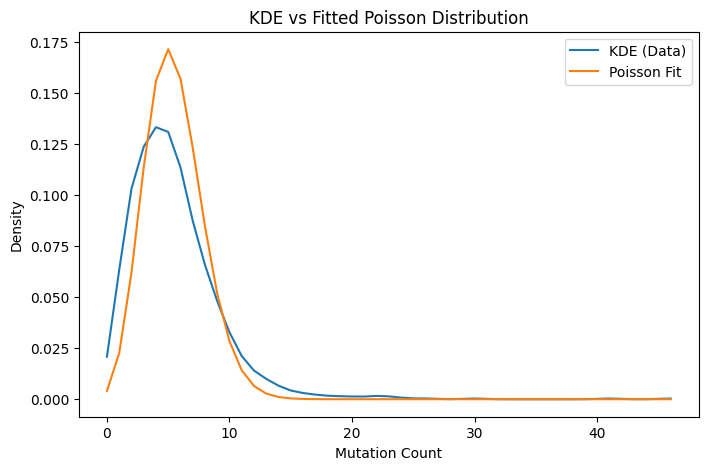

In [101]:
y = meta['Mutation Count']
lam = y.mean()
x = np.arange(0, int(y.max()) + 1)
kde = gaussian_kde(y)
kde_vals = kde(x)
pois_vals = poisson.pmf(x, lam)

plt.figure(figsize=(8,5))
plt.plot(x, kde_vals, label='KDE (Data)')
plt.plot(x, pois_vals, label=f'Poisson Fit')
plt.xlabel("Mutation Count")
plt.ylabel("Density")
plt.title("KDE vs Fitted Poisson Distribution")
plt.legend()
plt.show()


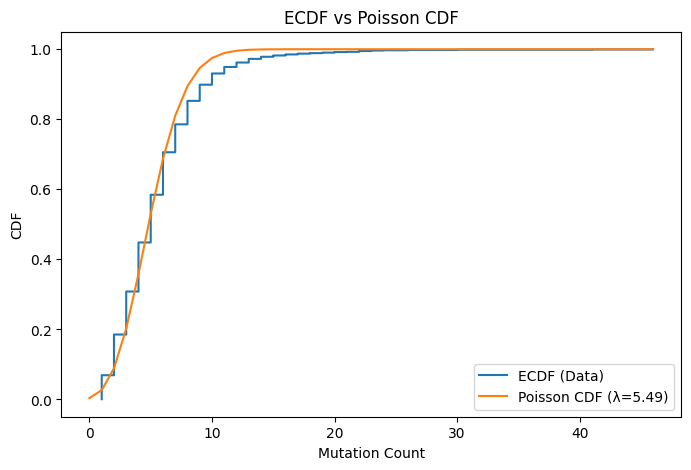

In [102]:
sorted_y = np.sort(y)
ecdf = np.arange(1, len(y)+1) / len(y)
pois_cdf = poisson.cdf(x, lam)

plt.figure(figsize=(8,5))
plt.step(sorted_y, ecdf, label='ECDF (Data)', where='post')
plt.plot(x, pois_cdf, label=f'Poisson CDF (λ={lam:.2f})')
plt.title("ECDF vs Poisson CDF")
plt.xlabel("Mutation Count")
plt.ylabel("CDF")
plt.legend()
plt.show()

Given the two graphs as you can see that they both fit pretty well. The KDE vs the poisson fits are a little less accurate. The Poisson distribution has a higher peak than the KDE but besides that they fit well. On the other hand the ECDF is more accurate it follows the poisson almost exactly. 

- Bootstrap the sampling density/distribution of your parameter.

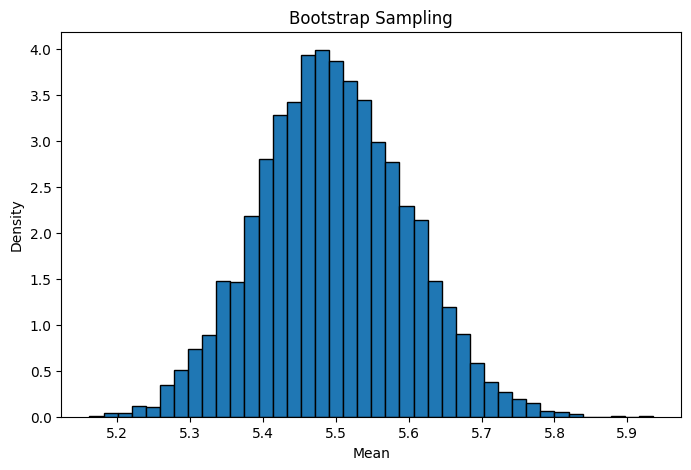

In [107]:
S = 5000
boot = np.zeros(S)
n = len(y)

for x in range(S):
    sample = np.random.choice(y, size=n, replace=True)
    boot[x] = sample.mean()  

plt.figure(figsize=(8,5))
plt.hist(boot, bins=40, density=True, edgecolor='black')
plt.title("Bootstrap Sampling")
plt.xlabel("Mean")
plt.ylabel("Density")
plt.show()